In [9]:
import pandas as pd

df = pd.read_csv(r"C:\Users\dell\Downloads\Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [11]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


=== DataFrame ===
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  


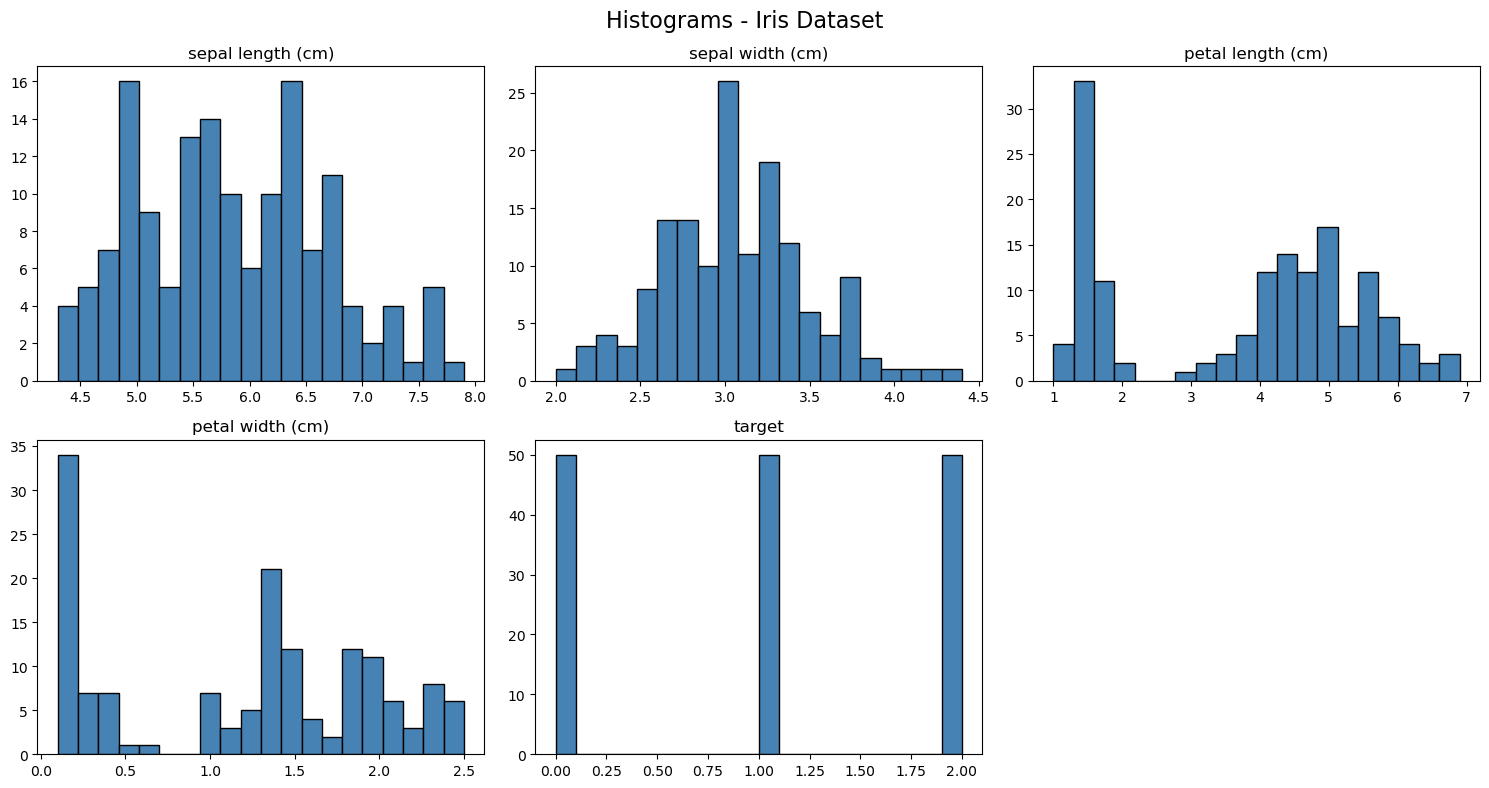

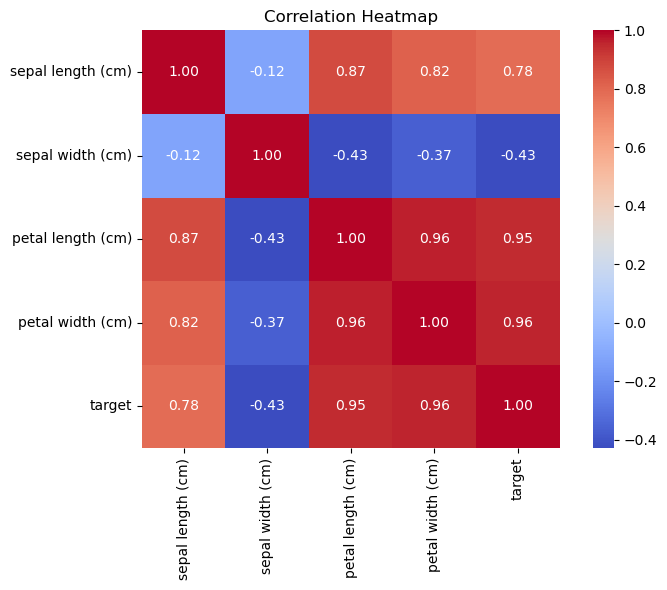

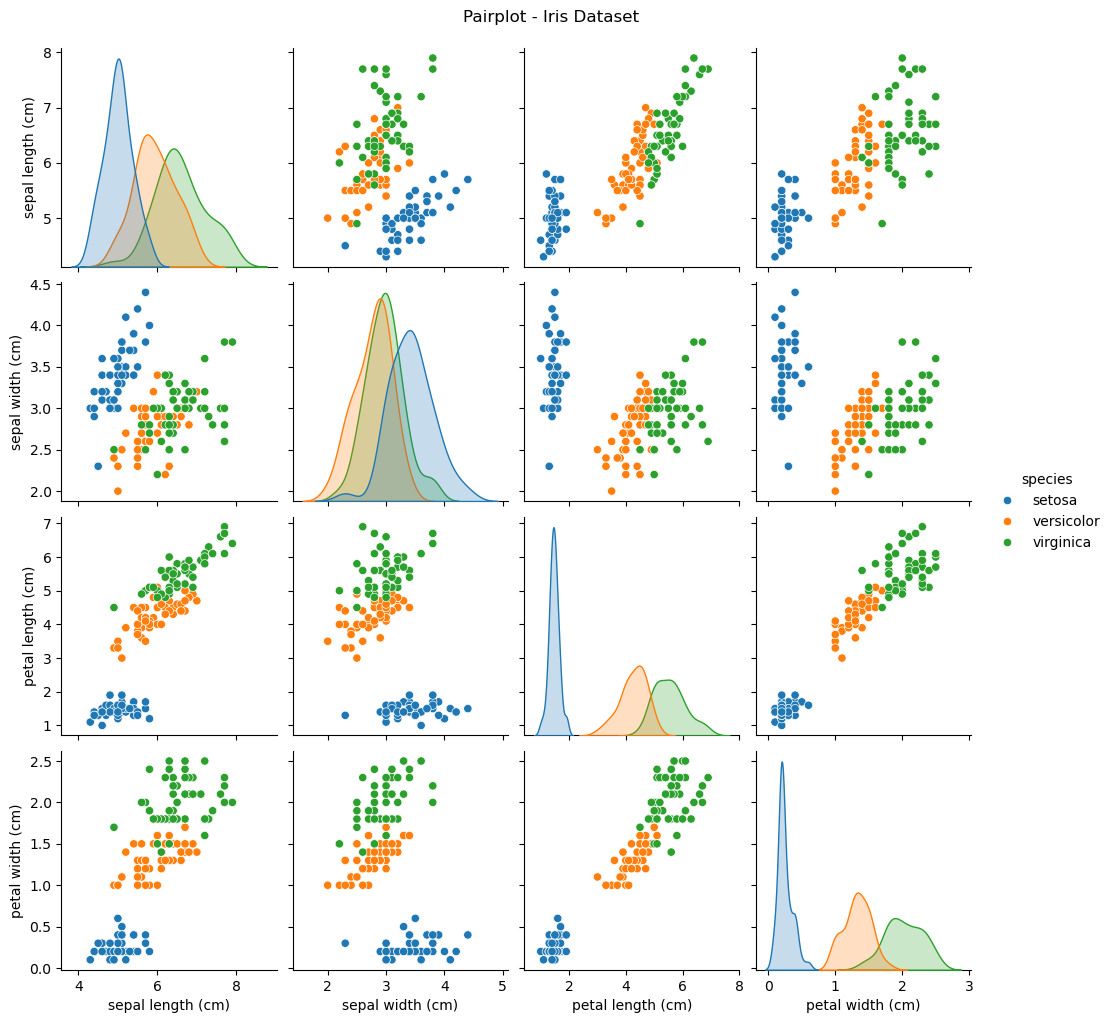


Normalized file saved as Dataset_Normalized_Iris.csv
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0           0.222222          0.625000           0.067797          0.041667   
1           0.166667          0.416667           0.067797          0.041667   
2           0.111111          0.500000           0.050847          0.041667   
3           0.083333          0.458333           0.084746          0.041667   
4           0.194444          0.666667           0.067797          0.041667   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  


In [13]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Load
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0:'setosa', 1:'versicolor', 2:'virginica'})

# (a) DataFrame
print("=== DataFrame ===")
print(df.head())

# (b) Histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Histograms - Iris Dataset', fontsize=16)
for i, col in enumerate(iris.feature_names + ['target']):
    ax = axes[i//3][i%3]
    ax.hist(df[col], bins=20, color='steelblue', edgecolor='black')
    ax.set_title(col)
axes[1][2].axis('off')
plt.tight_layout()
plt.savefig('histograms_iris.png', dpi=150)
plt.show()

# (c) Heatmap
plt.figure(figsize=(8,6))
corr = df[iris.feature_names + ['target']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('heatmap_iris.png', dpi=150)
plt.show()

# (d) Pairplot
sns.pairplot(df, hue='species', vars=iris.feature_names, diag_kind='kde')
plt.suptitle('Pairplot - Iris Dataset', y=1.02)
plt.savefig('pairplot_iris.png', dpi=150)
plt.show()

# (e) Normalize + Save
scaler = MinMaxScaler()
df_norm = df.copy()
df_norm[iris.feature_names] = scaler.fit_transform(df[iris.feature_names])
df_norm.to_csv('Dataset_Normalized_Iris.csv', index=False)
print("\nNormalized file saved as Dataset_Normalized_Iris.csv")
print(df_norm.head())